# Exercise 2: Wolff cluster updates
Each step of the Wolff algorithm consists of an iteration procedure to build a cluster of parallel spins with connected sites: At first, a random site $i$ is chosen to seed the cluster. Then, all neighbouring sites that have the same spin as the spin(s) in the cluster are added, each with probability $1-e^{-\beta J}$ (note that this is for $\sigma_i=0,1$. If you're taking $\sigma_i=-1,1$ then the probability would be $1-e^{-2\beta J}$). This is repeated until all boundaries of the cluster have been checked exactly once and no more sites are added. Then, the step is finished by flipping all spins of the cluster and thereby creating a new sample.
First of all, we write a class for the cluster updates.
In particular, we will need the following member functions:

- **update_probabilities**:
As in the Metropolis algorithm, we can reduce the computational cost by pre-computing the needed exponentials. Here, we only need to precompute one exponential $e^{-\beta J}$, which is saved in the member variable self.wolff_prob. Set the value of self.wolff_prob in **update_probabilities**.

- **set_temperature**:
(Re-)sets the temperature self.T (probability wolff_prob need to be updated when T is set or changed!) 

- **reset_spins**:
Sets the spins (array self.spins) to the initial configuration, which we here choose as all spins up. Keep in mind that we want to calculate the magnetization $\langle |m| \rangle=|1.0/L^2 \langle \sum_i s_i \rangle|$. For this, it is useful to keep track of the quantity $M=\sum_i s_i$ (member variable self.M) during the Metropolis algorithm. Set the initial value of $M$ in **reset_spins**.

- **wolff_step**: 
Performs one step of the wolff algorithm. Keep in mind to update self.M as well.

- **wolff_sweep**:
Performs one Monte Carlo sweep, consisting of $L*L$ steps.

*Hint (optional): It can be useful (with respect to the computational time) to store the indices of sites at the cluster boundaries with parallel spin using queue.Queue()*

In [1]:
import numpy as np
import random
import numba
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import pandas as pd
import scipy.optimize as spo

In [2]:
# Base Parameters
J = 1 
beta_steps = 75
beta = np.linspace(0.1, 0.8, beta_steps) 
Nthermalization_MRT2 = int(10e5) 
Nthermalization_Wolff = int(10e4)
Nsample = 2**14 


Tc_ground = 2 / np.log(1 + np.sqrt(2))

L_values = [4, 8, 16]

## Task 1

$p_{add} = 1-e^{2\beta J}$

## Task 2

#### (a)

In [3]:
class Index:
    '''utility class to make to wolff marginally more legible. holds an index pair. (Usage optional) '''
    def __init__(self, i, j):
        self.i = i
        self.j = j

@numba.njit
def _wolff_step_numba(spins, wolff_marker, L, wolff_prob):
    wolff_marker.fill(0)
    
    i0 = np.random.randint(0, L)
    j0 = np.random.randint(0, L)
    ground_spin = spins[i0, j0]
    wolff_marker[i0, j0] = 1
    
    # use a simple array-based stack instead of list of tuples
    stack = np.zeros((L*L, 2), dtype=np.int64)
    stack[0, 0] = i0
    stack[0, 1] = j0
    stack_size = 1
    
    dirs = [(-1,0),(1,0),(0,-1),(0,1)]
    while stack_size > 0:
        stack_size -= 1
        ci = stack[stack_size, 0]
        cj = stack[stack_size, 1]
        for d in range(4):
            ni = (ci + dirs[d][0]) % L
            nj = (cj + dirs[d][1]) % L
            if wolff_marker[ni, nj] == 0 and spins[ni, nj] == ground_spin:
                if np.random.random() < wolff_prob:
                    wolff_marker[ni, nj] = 1
                    stack[stack_size, 0] = ni
                    stack[stack_size, 1] = nj
                    stack_size += 1
    
    N_cluster = np.sum(wolff_marker == 1)
    spins[wolff_marker == 1] *= -1
    return spins, N_cluster, ground_spin

@numba.njit
def _wolff_step_numba(spins, wolff_marker, L, wolff_prob):
    wolff_marker.fill(0)
    
    i0 = np.random.randint(0, L)
    j0 = np.random.randint(0, L)
    ground_spin = spins[i0, j0]
    wolff_marker[i0, j0] = 1
    
    stack = np.zeros((L*L, 2), dtype=np.int64)
    stack[0, 0] = i0
    stack[0, 1] = j0
    stack_size = 1
    
    while stack_size > 0:
        stack_size -= 1
        ci = stack[stack_size, 0]
        cj = stack[stack_size, 1]
        for d in range(4):
            ni = (ci + (d==1) - (d==0)) % L
            nj = (cj + (d==3) - (d==2)) % L
            if wolff_marker[ni, nj] == 0 and spins[ni, nj] == ground_spin:
                if np.random.random() < wolff_prob:
                    wolff_marker[ni, nj] = 1
                    stack[stack_size, 0] = ni
                    stack[stack_size, 1] = nj
                    stack_size += 1
    
    # replace boolean indexing with explicit loop
    N_cluster = 0
    for i in range(L):
        for j in range(L):
            if wolff_marker[i, j] == 1:
                spins[i, j] *= -1
                N_cluster += 1
    
    return spins, N_cluster, ground_spin

class IsingMC_Wolff:
    def __init__(self, length, temperature=0.):
        self.spins = np.random.choice([-1, 1], size=(length, length)).astype(int)
        self.L = length
        self.T = temperature
        self.M = int(np.sum(self.spins))
        self.wolff_prob = None
        self.wolff_marker = np.zeros((length,length),dtype=int) #container to mark which sites are in the cluster
        self.update_probabilities()
    
    def update_probabilities(self):
        '''we calculate the probability in the beginning so we don't have to recompute it'''
        if(self.T != 0.):
            self.wolff_prob = 1. - np.exp(-2./self.T)
           
        else:
            self.wolff_prob = 1. #at zero temperature we always add to the cluster
          
    def set_temperature(self, temperature):
        '''set temperature and update the probability'''
        self.T = temperature
        self.update_probabilities()
    
    def reset_spins(self):
        '''this resets the spins to the all-up state '''
        self.spins.fill(1)
        self.M = self.L * self.L

    def magnetisation(self):
        return np.abs(self.M) / (self.L ** 2)

    def update_magnetisation(self, ground_spin):
        """call this after building cluster but before flipping"""
        N_cluster = np.sum(self.wolff_marker == 1)
        self.M -= 2 * ground_spin * N_cluster

    def wolff_step(self):
        self.spins, N_cluster, ground_spin = _wolff_step_numba(
            self.spins, self.wolff_marker, self.L, self.wolff_prob)
        self.M -= 2 * ground_spin * N_cluster

    def run_binning_analysis_wolff(self, Nsamples, Ninit, max_l):
        """ implements the binning method for computing the autocorrelation time. """

        # Nsamples = total number of samples to obtain (after discarding thermalising)
        # Ninit = numer of initial samples to discard in the beggining of the simulation
        # max_l = maximum level of binning, with 2**max_l samples in each bin
        
        assert np.log2(Nsamples).is_integer() # works only for  Nsamples =  power of two

        self.spins = np.random.choice([-1, 1], size=(self.L, self.L))
        self.M = int(np.sum(self.spins))  # sync M with the newly drawn spins

        #thermalisation
        for _ in range(Ninit):
            self.wolff_step()

        #sample
        M_data = np.zeros(Nsamples)

        start = time.perf_counter()
        for step in range(Nsamples):
            self.wolff_step()
            M_data[step] = self.magnetisation()
        time_Wolff = time.perf_counter() - start


        M0 = Nsamples
        M_mean = np.mean(M_data) # note that the mean is unaffected by binning)
        
        Delta_ls = []
        Als = np.copy(M_data)
        for l in range(max_l):
            Ml = M0/(2**l)
            Delta_l = np.sqrt(1/(Ml*(Ml-1)) * np.sum((Als-M_mean)**2))
            Delta_ls.append(Delta_l)

            Als = np.copy((Als[::2] + Als[1::2])/2)
            
        return np.array(Delta_ls), time_Wolff

@numba.njit
def _move_MRT2_numba(spins, L, J, beta, moves):
    
    delta_M = 0
    for _ in range(moves):
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)

        h = spins[(i+1)%L, j] + spins[(i-1)%L, j] + spins[i, (j+1)%L] + spins[i, (j-1)%L]
        delta_E = 2 * J * h * spins[i, j]

        # cunda can't handle look up table so do it manually
        if delta_E <= 0:
            R = 1.0
        elif delta_E == 4:
            R = np.exp(-4 * beta)
        else:  # delta_E == 8
            R = np.exp(-8 * beta)

        if np.random.random() < R:
            spins[i, j] *= -1
            delta_M += 2 * spins[i, j]
    return delta_M

class IsingMRT2:
    def __init__(self, length, beta=0, J=1):
        self.spins = np.random.choice([-1, 1], size=(length, length))
        self.J = J
        self.L = length
        self.beta = beta
        self.M = int(np.sum(self.spins))
        self.E = self.total_energy()

    def nn_sum(self, i, j):
        x = self.spins
        result = x[(i+1)%self.L, j] + x[(i-1)%self.L, j] + x[i, (j+1)%self.L] + x[i, (j-1)%self.L]
        return int(result)

    def total_energy(self):
        energy = 0
        for i in range(self.L):
            for j in range(self.L):
                energy -= self.J * self.spins[i, j] * self.nn_sum(i, j)
        return energy / 2
    
    def sweep(self, N):
        delta_M = _move_MRT2_numba(self.spins, self.L, self.J, self.beta, N)
        self.M += delta_M
    
    def magnetisation(self):
        return np.abs(self.M) / self.L**2
    
    def run_binning_analysis_MRT(self, Nsamples, Ninit, max_l):
        """ implements the binning method for computing the autocorrelation time. """

        # Nsamples = total number of samples to obtain (after discarding thermalising)
        # Ninit = numer of initial samples to discard in the beggining of the simulation
        # max_l = maximum level of binning, with 2**max_l samples in each bin
        
        assert np.log2(Nsamples).is_integer() # works only for  Nsamples =  power of two

        self.spins = np.random.choice([-1, 1], size=(self.L, self.L))
        A0s = []

        #thermalisation
        for _ in range(Ninit):
            self.sweep(self.L**2)

        #sample
        M_data = np.zeros(Nsamples)

        start = time.perf_counter()
        for step in range(Nsamples):
            self.sweep(self.L**2)
            M_data[step] = self.magnetisation()
        time_MRT2 = time.perf_counter() - start


        M0 = Nsamples
        M_mean = np.mean(M_data) # note that the mean is unaffected by binning)
        
        Delta_ls = []
        Als = np.copy(M_data)
        for l in range(max_l):
            Ml = M0/(2**l)
            Delta_l = np.sqrt(1/(Ml*(Ml-1)) * np.sum((Als-M_mean)**2))
            Delta_ls.append(Delta_l)

            Als = np.copy((Als[::2] + Als[1::2])/2)
            
        return np.array(Delta_ls), time_MRT2

### Wolff

In [4]:
Tc_chi_Wolff = {}
M_Wolff = {}
M_Wolff_err = {}
chi_Wolff = {}
binder_Wolff = {}

for L in L_values:
    N = L**2

    M_temp = np.zeros_like(beta)
    chi_temp = np.zeros_like(beta) 
    binder_temp = np.zeros_like(beta)

    for i, beta_val in enumerate(tqdm(beta, desc=f'L={L}')):
        ising_wolff = IsingMC_Wolff(L, temperature=1/beta[i])

        #thermalisation
        for _ in range(Nthermalization_Wolff):
            ising_wolff.wolff_step()

        #sample
        M_data = np.zeros(Nsample)

        for step in range(Nsample):
            ising_wolff.wolff_step()
            M_data[step] = ising_wolff.magnetisation()
            #abs value would be needed here but since even exponent doesnt matter

        M_temp[i] = np.mean(M_data) 
        chi_temp[i] = N * beta[i] * (np.mean(M_data**2) - np.mean(M_data)**2) 
        
        binder_temp[i] = 1 - np.mean(M_data**4) / (3 * np.mean(M_data**2)**2)
    

    L_temp = L_values.index(L) 

    #Tc_chi_Wolff[L_temp] = 1 / beta[np.argmax(chi_temp)]
    M_Wolff[L_temp] = M_temp 
    M_Wolff_err[L_temp] = np.std(M_data)
    chi_Wolff[L_temp] = chi_temp
    binder_Wolff[L_temp] = binder_temp

    Tc_chi_Wolff= 1 / beta[np.argmax(chi_temp)]
  


L=16: 100%|██████████| 75/75 [00:48<00:00,  1.55it/s]


### MRT2

In [5]:
Tc_chi_MRT2 = {}
M_MRT2 = {}
M_MRT2_err = {}
chi_MRT2 = {}
binder_MRT2 = {}

for L in L_values:
    N = L**2
    Nsubsweep = 10 * N 

    M_temp = np.zeros_like(beta)
    chi_temp = np.zeros_like(beta) 
    binder_temp = np.zeros_like(beta)

    for i, beta_val in enumerate(tqdm(beta, desc=f'L={L}')):
        ising_mrt2 = IsingMRT2(L, beta_val)
        spins = ising_mrt2.spins

        #thermalisation
        for _ in range(Nthermalization_MRT2):
            ising_mrt2.sweep(N)

        #sample
        M_data = np.zeros(Nsample)

        for step in range(Nsample):
            ising_mrt2.sweep(N)
            M_data[step] = ising_mrt2.magnetisation()

        M_temp[i] = np.mean(M_data) 
        chi_temp[i] = N * beta[i] * (np.mean(M_data**2) - np.mean(M_data)**2) 

        binder_temp[i] = 1 - np.mean(M_data**4) / (3 * np.mean(M_data**2)**2)

    L_temp = L_values.index(L)

    M_MRT2[L_temp] = M_temp 
    M_MRT2_err[L_temp] = np.std(M_data)
    chi_MRT2[L_temp] = chi_temp
    binder_MRT2[L_temp] = binder_temp

    Tc_chi_MRT2[L_values.index(L)] = 1 / beta[np.argmax(chi_temp)]

L=16: 100%|██████████| 75/75 [06:57<00:00,  5.56s/it]


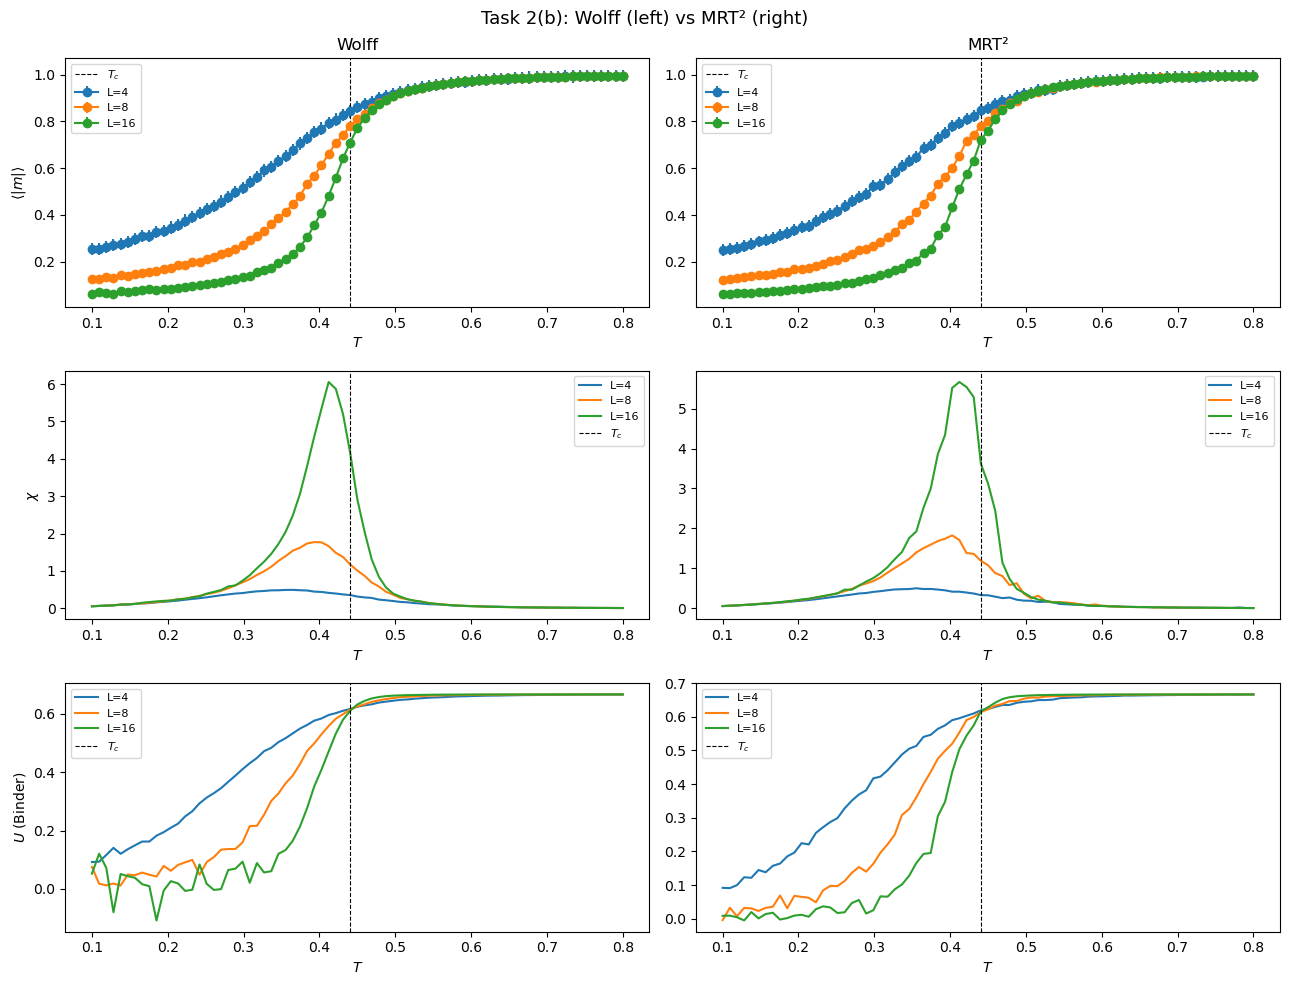

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(13, 10))
fig.suptitle('Task 2(b): Wolff (left) vs MRT² (right)', fontsize=13)

colors = plt.cm.tab10.colors

for L in L_values:
    label = f'L={L}'

    axes[0, 0].errorbar(beta, M_Wolff[L_values.index(L)], yerr=M_Wolff_err[L_values.index(L)], fmt='-o', color=colors[L_values.index(L)], label=label)
    axes[0, 1].errorbar(beta, M_MRT2[L_values.index(L)], yerr=M_MRT2_err[L_values.index(L)], fmt='-o', color=colors[L_values.index(L)], label=label)
    axes[1, 0].plot(beta, chi_Wolff[L_values.index(L)], color=colors[L_values.index(L)], label=label)
    axes[1, 1].plot(beta, chi_MRT2[L_values.index(L)],  color=colors[L_values.index(L)], label=label)
    axes[2, 0].plot(beta, binder_Wolff[L_values.index(L)],   color=colors[L_values.index(L)], label=label)
    axes[2, 1].plot(beta, binder_MRT2[L_values.index(L)],    color=colors[L_values.index(L)], label=label)

for ax in axes.flat:
    ax.axvline(1 / Tc_ground, color='k', ls='--', lw=0.8, label='$T_c$')
    ax.set_xlabel('$T$')
    ax.legend(fontsize=8)

axes[0, 0].set_ylabel(r'$\langle|m|\rangle$')
axes[1, 0].set_ylabel(r'$\chi$')
axes[2, 0].set_ylabel(r'$U$ (Binder)')
axes[0, 0].set_title('Wolff')
axes[0, 1].set_title('MRT²')

plt.tight_layout()
plt.savefig('task2_observables.pdf', bbox_inches='tight')
plt.show()

## Task 3

#### Bonus a

In [7]:
random.seed(42)
np.random.seed(42)

#from google.colab import drive
#drive.mount('/content/gdrive')

#cd'gdrive/MyDrive/Colab Notebooks/CSP'

class IsingMC_Metropolis:
    def __init__(self, length, temperature=0.):
        self.spins = np.ones((length,length),dtype=int) #2D array of spins, corresponds to the current configuration
        self.L = length
        self.T = temperature
        self.M = length * length #magnetization, we start with all spins up
        self.mrt_prob = None  #should be set to array of length 8 in update_probabilities.
        self.update_probabilities()
    
   
    def update_probabilities(self):
        '''we tabularize the probabilities using self.mrt_prob so we don't have to recompute them '''
        if(self.T != 0.):
            #ising acceptance probabilities
            #access using the index 4 + s_i * h_i
            self.mrt_prob = np.array([np.exp(8./self.T),0.,np.exp(4./self.T),0.,1.,0.,np.exp(-4./self.T),0.,np.exp(-8./self.T)])
        else:
            #ising acceptance probabilities
            #access using the index 4 + s_i * h_i
            self.mrt_prob = np.array([1.,0.,1.,0.,1.,0.,0.,0.,0.])
        
    
    def set_temperature(self, temperature):
        '''set temperature and update the probabilities '''
        self.T = temperature
        self.update_probabilities()
        
    
    def reset_spins(self):
        '''this resets the spins to the all-up state '''
        self.spins.fill(1)
        self.M = self.L * self.L  


    def mrt_step(self):
        '''performs one update step using single spin Metropolis'''
        index1 = random.randint(0,self.L-1)
        index2 = random.randint(0,self.L-1)
        sihi = self.spins[index1][index2] * (self.spins[(index1 + 1) % self.L][index2] 
             + self.spins[index1 - 1][index2] + self.spins[index1][(index2 + 1) % self.L] +
              self.spins[index1][index2 - 1])
        if self.mrt_prob[sihi+4] > random.random():
            self.spins[index1][index2] *= -1 #flip
            self.M += 2.*self.spins[index1][index2] #track magnetization

    def mrt_sweep(self):
        """performs one sweep of updates"""
        for _ in range(self.L**2):
            self.mrt_step()

    def mrt_equilibrate(self, n_0):
        for _ in range(n_0):
            self.mrt_step()

    def run_binning_analysis(self, Nsamples, Ninit, max_l):
        """ implements the binning method for computing the autocorrelation time. """

        # Nsamples = total number of samples to obtain (after discarding thermalising)
        # Ninit = numer of initial samples to discard in the beggining of the simulation
        # max_l = maximum level of binning, with 2**max_l samples in each bin
        
        assert np.log2(Nsamples).is_integer() # works only for  Nsamples =  power of two

        self.reset_spins()
        A0s = []

        for _ in range(Ninit): # initial thermalisation
            self.mrt_sweep()

        start = time.perf_counter()
        for i in range(Nsamples): # simulation
            self.mrt_sweep()
            A0s.append(self.M/self.L**2)
        end = time.perf_counter()

        A0s = np.array(A0s)
        M0 = Nsamples
        A_mean = np.mean(A0s) # note that the mean is unaffected by binning)
        
        Delta_ls = []
        Als = np.copy(A0s)
        for l in range(max_l):
            Ml = M0/(2**l)
            Delta_l = np.sqrt(1/(Ml*(Ml-1)) * np.sum((Als-A_mean)**2))
            Delta_ls.append(Delta_l)

            Als = np.copy((Als[::2] + Als[1::2])/2)
            
        return np.array(Delta_ls), end - start



### fixed L

In [8]:
Npower = 14
Nsamples = 2**Npower
Ninit = 2000
T_c = 2 / np.log(1 + np.sqrt(2))

max_l = Npower-5 # 2**5 = 32 = minimum number of bins

Ts = np.array([T_c - 1, T_c - 0.5, T_c, T_c + 0.5, T_c + 1, T_c + 1.5]) # last 3 can be compared to previous exercise

L = 16

##### Wolff

In [9]:
Delta_lTs_Wolff_L_fix = []
Time_Wolff_L_fix = []

for T in tqdm(Ts, desc=f'L={L}'):
    mrt_sim = IsingMC_Wolff(L, T)
    Delta_ls, Time_Wolff = mrt_sim.run_binning_analysis_wolff(Nsamples, Ninit, max_l)
    Delta_lTs_Wolff_L_fix.append(Delta_ls)
    Time_Wolff_L_fix.append(Time_Wolff)

Delta_lTs_Wolff_L_fix = np.array(Delta_lTs_Wolff_L_fix)
Time_Wolff_L_fix = np.array(Time_Wolff_L_fix)

taus_bin = 1/2*((np.amax(Delta_lTs_Wolff_L_fix, axis=1)/Delta_lTs_Wolff_L_fix[:, 0])**2-1)

MC_speed_Wolff_L_fix = Nsamples / (Time_Wolff_L_fix * taus_bin)

L=16: 100%|██████████| 6/6 [00:00<00:00, 10.05it/s]


##### MRT2

L=16: 100%|██████████| 6/6 [00:00<00:00,  7.74it/s]


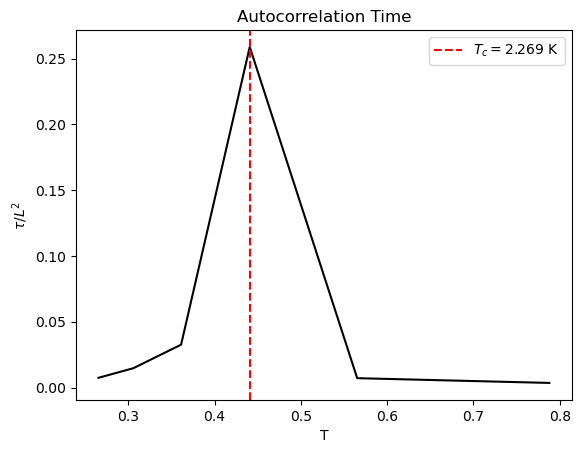

In [10]:
Delta_lTs_MRT_L_fix = []
Time_MRT2s_L_fix = []

for T in tqdm(Ts, desc=f'L={L}'):
    mrt_sim = IsingMRT2(L, 1.0/T)
    Delta_ls, Time_MRT2 = mrt_sim.run_binning_analysis_MRT(Nsamples, Ninit, max_l)
    Delta_lTs_MRT_L_fix.append(Delta_ls)
    Time_MRT2s_L_fix.append(Time_MRT2)

Delta_lTs_MRT_L_fix = np.array(Delta_lTs_MRT_L_fix)
Time_MRT2s_L_fix = np.array(Time_MRT2s_L_fix)

taus_bin = 1/2*((np.amax(Delta_lTs_MRT_L_fix, axis=1)/Delta_lTs_MRT_L_fix[:, 0])**2-1)

MC_speed_MRT_L_fix = Nsamples / (Time_MRT2s_L_fix * taus_bin)

plt.plot(1/Ts, taus_bin/L**2, "-k")
plt.axvline(1/T_c, label="$T_c = 2.269$ K", ls="--", c="r")

plt.title("Autocorrelation Time")
plt.ylabel("$\\tau/L^2$")
plt.xlabel("T")
plt.legend()

#### MRTGT

In [11]:
Delta_lTs_MRTGT_L_fix = []
Time_MRTGT_L_fix = []

for T in tqdm(Ts, desc=f'L={L}'):
    sys = IsingMC_Metropolis(L, T)
    Delta_ls, Time_MRTGT = sys.run_binning_analysis(Nsamples, Ninit, max_l)
    Delta_lTs_MRTGT_L_fix.append(Delta_ls)
    Time_MRTGT_L_fix.append(Time_MRTGT)


Delta_lTs_MRTGT_L_fix = np.array(Delta_lTs_MRTGT_L_fix)
Time_MRTGT_L_fix = np.array(Time_MRTGT_L_fix)

taus_bin = 1/2*((np.amax(Delta_lTs_MRTGT_L_fix, axis=1)/Delta_lTs_MRTGT_L_fix[:, 0])**2-1)
MC_speed_MRTGT_L_fix = Nsamples / (Time_MRTGT_L_fix * taus_bin)


L=16: 100%|██████████| 6/6 [00:53<00:00,  8.87s/it]


## fixed T

In [12]:
L = np.array([4, 8, 16, 32, 64])

#### Wolff

In [13]:
Delta_lTs_Wolff_T_fix = []
Time_Wolff_T_fix = []

for i in tqdm(L, desc=f'T={T}'):
    mrt_sim = IsingMC_Wolff(i, T_c)
    Delta_ls, Time_Wolff = mrt_sim.run_binning_analysis_wolff(Nsamples, Ninit, max_l)
    Delta_lTs_Wolff_T_fix.append(Delta_ls)
    Time_Wolff_T_fix.append(Time_Wolff)

Delta_lTs_Wolff_T_fix = np.array(Delta_lTs_Wolff_T_fix)
Time_Wolff_T_fix = np.array(Time_Wolff_T_fix)

taus_bin = 1/2*((np.amax(Delta_lTs_Wolff_T_fix, axis=1)/Delta_lTs_Wolff_T_fix[:, 0])**2-1)

MC_speed_Wolff_T_fix = Nsamples / (Time_Wolff_T_fix * taus_bin)

T=3.769185314213022: 100%|██████████| 5/5 [00:02<00:00,  2.22it/s]


#### MRT2

In [14]:
Delta_lTs_MRT_T_fix = []
Time_MRT2s_T_fix = []

for L in tqdm(L, desc=f'T={T}'):
    mrt_sim = IsingMRT2(L, 1.0/T_c)
    Delta_ls, Time_MRT2 = mrt_sim.run_binning_analysis_MRT(Nsamples, Ninit, max_l)
    Delta_lTs_MRT_T_fix.append(Delta_ls)
    Time_MRT2s_T_fix.append(Time_MRT2)

Delta_lTs_MRT_T_fix = np.array(Delta_lTs_MRT_T_fix)
Time_MRT2s_T_fix = np.array(Time_MRT2s_T_fix)

taus_bin = 1/2*((np.amax(Delta_lTs_MRT_T_fix, axis=1)/Delta_lTs_MRT_T_fix[:, 0])**2-1)

MC_speed_MRT_T_fix = Nsamples / (Time_MRT2s_T_fix * taus_bin)

T=3.769185314213022: 100%|██████████| 5/5 [00:02<00:00,  2.30it/s]


### MRTGT

In [15]:
Delta_lTs_MRTGT_T_fix = []
Time_MRTGT_T_fix = []

L = np.array([4, 8, 16, 32, 64])

for L in tqdm(L, desc=f'T={T}'):
    sys = IsingMC_Metropolis(L, T_c)
    Delta_ls, Time_MRTGT = sys.run_binning_analysis(Nsamples, Ninit, max_l)
    Delta_lTs_MRTGT_T_fix.append(Delta_ls)
    Time_MRTGT_T_fix.append(Time_MRTGT)

Delta_lTs_MRTGT_T_fix = np.array(Delta_lTs_MRTGT_T_fix)
Time_MRTGT_T_fix = np.array(Time_MRTGT_T_fix)

taus_bin = 1/2*((np.amax(Delta_lTs_MRTGT_T_fix, axis=1)/Delta_lTs_MRTGT_T_fix[:, 0])**2-1)
MC_speed_MRTGT_T_fix = Nsamples / (Time_MRTGT_T_fix * taus_bin)

T=3.769185314213022: 100%|██████████| 5/5 [03:13<00:00, 38.72s/it]


In [16]:
def export_mc_speeds_to_csv_L_fix(file_path, arrays):
    """
    Combines six arrays into a CSV file with headers.
    'arrays' should be a list or tuple of the 6 arrays in order.
    """
    # Define the headers based on your array names
    headers = [
        "Wolff_L_fix", "MRT_L_fix", "MRTGT_L_fix",
    ]
    
    # Create a dictionary mapping headers to arrays
    data = {headers[i]: arrays[i] for i in range(len(headers))}
    
    # Create DataFrame and save to CSV
    df = pd.DataFrame(data)
    df.to_csv(file_path, index=False, float_format='%.2f')

            

def export_mc_speeds_to_csv_T_fix(file_path, arrays):
    """
    Combines six arrays into a CSV file with headers.
    'arrays' should be a list or tuple of the 6 arrays in order.
    """
    # Define the headers based on your array names
    headers = [
        "Wolff_T_fix", "MRT_T_fix", "MRTGT_T_fix"
    ]
    
    # Create a dictionary mapping headers to arrays
    data = {headers[i]: arrays[i] for i in range(len(headers))}
    
    # Create DataFrame and save to CSV
    df = pd.DataFrame(data)
    df.to_csv(file_path, index=False, float_format='%.2f')

# Example usage:
L_arrays = [MC_speed_Wolff_L_fix, MC_speed_MRT_L_fix, MC_speed_MRTGT_L_fix]
T_arrays = [MC_speed_Wolff_T_fix, MC_speed_MRT_T_fix, MC_speed_MRTGT_T_fix]
export_mc_speeds_to_csv_L_fix("mc_results_L_fix.csv", L_arrays)
export_mc_speeds_to_csv_T_fix("mc_results_T_fix.csv", T_arrays)